In [2]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Test2_consolidation.xlsx")

# Label distribution after consolidation

Check of the label distribution of the final tags/labels of the whole Test 2 after the finished consolidation.

Observations: 
- P_Neutral label seems to be the most frequent, though this is easily explained by a large percentage of the procedual speeches included in the test dataset (as well as in the original whole ParlaMint-SI dataset/corpus)
- Negative label in much smaller percentage (cf. explanation of the P_Neutral label above)
- Mixed labels (M_Negative and M_Positive, total 6 labels out of 50)
- Positive label: unexpectedly, not the least frequent label

**Note**: After main annotation, the comparison of label distribution should be done to check the distribution of labels between sentence and utterance annotation (check options for fair comparison, as the datasets are different in terms of content as well as size)

In [4]:
label_counts = df['final_tag'].value_counts()

In [5]:
print(label_counts)

final_tag
P_Neutral     28
Negative      12
M_Negative     4
Positive       3
M_Positive     2
N_Neutral      1
Name: count, dtype: int64


/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_14143/2451988151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


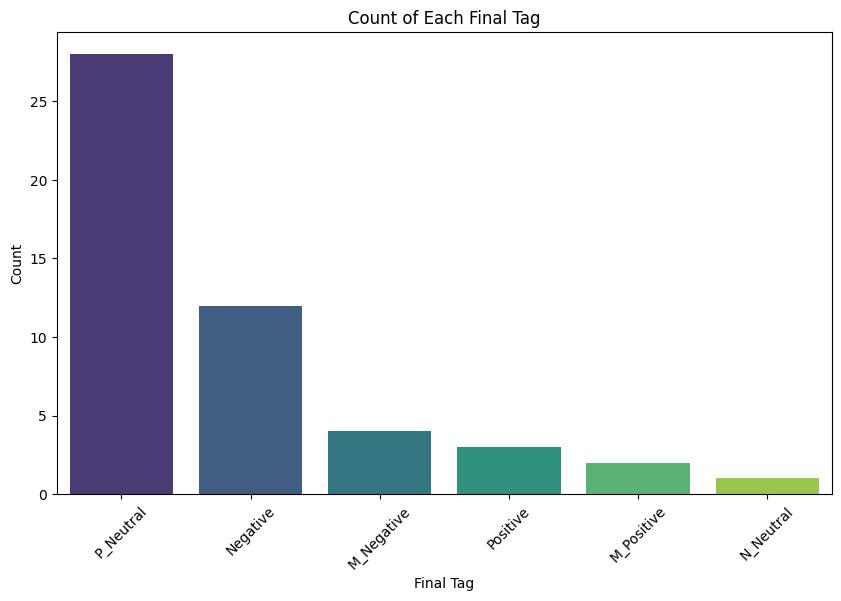

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.xlabel('Final Tag')
plt.ylabel('Count')
plt.title('Count of Each Final Tag')
plt.xticks(rotation=45)
plt.show()

# Label distribution of non-procedural speeches

As the datasets contain almost 50% of procedural speeches, where the used labels are limited to N_Neutral and P_Neutral, the analysis of the non-procedural speeches is needed to better inspect the sentiment in them. 

Observations: 
- Negative label much more present than any other label (unsurprisngly)
- Second most used label seems to be "P_Neutral". From the annotation process, the speeches, annotated with the P_Neutral label were mostly very procedural in nature (speakers were mostly presenting very statement-like arguments/descriptions of the procedures/amandments etc). 
- Other labels are mostly reflected from the final_tag analysis of the whole test dataset

In [7]:
df_non = df[df['chair']!= True]

In [8]:
df_non_final = df_non['final_tag'].value_counts()

In [9]:
df_non_final

final_tag
Negative      12
P_Neutral      5
M_Negative     4
Positive       3
M_Positive     2
Name: count, dtype: int64

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_14143/366801011.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_non_final.index, y=df_non_final.values, palette='viridis')


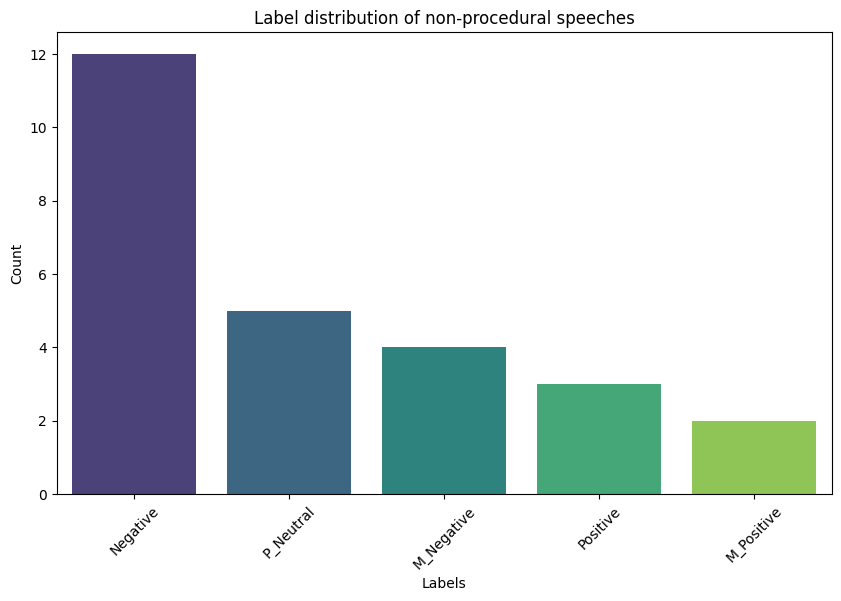

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_non_final.index, y=df_non_final.values, palette='viridis')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Label distribution of non-procedural speeches')
plt.xticks(rotation=45)
plt.show()

# Label distribution per annotator

To get a better feel for the annotation process, the comparison of labels used throughout the annotation process by the annotators is provided. 

Observations:
- In comparison to annotator1, annotator2 used Mixed and Negative labels more frequently (note very small sample here), whereas annotator1 seemed to prefer using P_/N_Neutral labels. 
- This is further emphasised in the analysis of the labels distribution per annotator for the non-procedural speech.

In [11]:
annotator1_label_count = df['tag_tamara'].value_counts()
annotator2_label_count = df['tag_katja'].value_counts()

In [12]:
print(annotator1_label_count)

tag_tamara
P_Neutral     28
Negative      11
N_Neutral      4
Positive       4
M_Positive     2
M_Negative     1
Name: count, dtype: int64


In [13]:
print(annotator2_label_count)

tag_katja
P_Neutral     26
Negative      12
M_Positive     5
M_Negative     3
Positive       2
N_Neutral      2
Name: count, dtype: int64


In [14]:
df2 = pd.DataFrame({
    'annotator1': annotator1_label_count,
    'annotator2': annotator2_label_count
}).fillna(0)

In [15]:
df2 = df2.reset_index().rename(columns={'index': 'label'})
df2

,label,annotator1,annotator2
0,M_Negative,1,3
1,M_Positive,2,5
2,N_Neutral,4,2
3,Negative,11,12
4,P_Neutral,28,26
5,Positive,4,2


In [16]:
df2 = df2.melt(id_vars='label', var_name='annotator', value_name='count')

In [17]:
df2

,label,annotator,count
0,M_Negative,annotator1,1
1,M_Positive,annotator1,2
2,N_Neutral,annotator1,4
3,Negative,annotator1,11
4,P_Neutral,annotator1,28
5,Positive,annotator1,4
6,M_Negative,annotator2,3
7,M_Positive,annotator2,5
8,N_Neutral,annotator2,2
9,Negative,annotator2,12


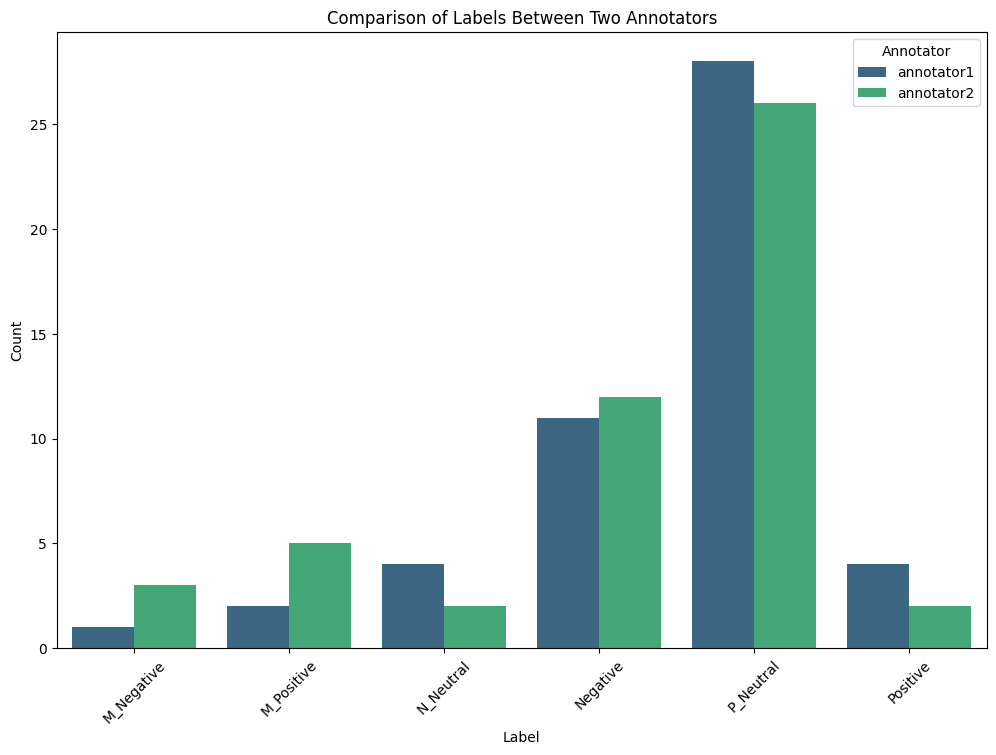

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=df2, palette='viridis')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

# Label distribution per annotator (non-procedural)

Cf. above, comparison of the label distributions used by the annotators when annotating the non-procedural speeches.

Observations:
- annotator2 favoured use of Mixed labels (of course, barring the use of Negative label, where the deviation between annotators is only 1)
- annotator2 did not use any N_Neutral (for the non-procedural speech), while the annotator1 did use them for several instances (again, keep in mind relatively small sample of 26 instanced of non-procedural sample out of 50 instatnces total)
- annotator1 in comparison leaned toward the more positive side with the use of Positive and P_Neutral label

In [19]:
annotator1_non_procedural = df_non['tag_tamara'].value_counts()
annotator2_non_procedural = df_non['tag_katja'].value_counts()

In [20]:
df3 = pd.DataFrame({
    'annotator1': annotator1_non_procedural,
    'annotator2': annotator2_non_procedural
}).fillna(0)

In [21]:
df3 = df3.reset_index().rename(columns={'index':'label'})

In [22]:
df3 = df3.melt(id_vars='label', var_name='annotator', value_name='count')
df3

,label,annotator,count
0,M_Negative,annotator1,1.0
1,M_Positive,annotator1,2.0
2,N_Neutral,annotator1,3.0
3,Negative,annotator1,11.0
4,P_Neutral,annotator1,5.0
5,Positive,annotator1,4.0
6,M_Negative,annotator2,3.0
7,M_Positive,annotator2,5.0
8,N_Neutral,annotator2,0.0
9,Negative,annotator2,12.0


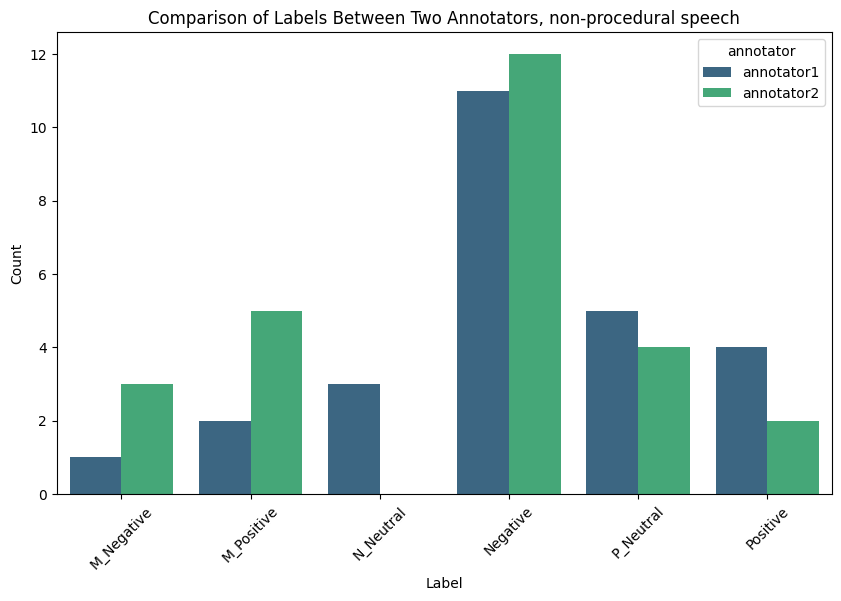

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(x='label', y='count', hue='annotator', data=df3, palette='viridis')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators, non-procedural speech')
plt.xticks(rotation=45)
plt.show()
